# AI-Driven Fashion Generation

Welcome to the **Midnight Monolith** project. This notebook explores the intersection of deep learning and avant-garde fashion design. The primary objective is to build and train custom generative AI models—specifically a Variational Autoencoder (VAE) and a Deep Convolutional GAN (DCGAN)—from scratch to synthesize an entirely new garment collection.

###  The Engineering Strategy
Working under strict hackathon compute limits requires strategic data handling. Rather than attempting to generate high-fidelity, full-color images (which often results in chaotic color noise), this project embraces a deliberate, minimalist aesthetic. 

By preprocessing the source dataset into high-contrast grayscale, we force the neural networks to bypass color mapping and focus exclusively on learning the fundamental **geometry, structure, and silhouette** of the clothing. The final output is a sleek, unified digital capsule collection that prioritizes architectural form over color.

In [7]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, metrics, backend as K

# Hide TensorFlow warnings for a clean notebook
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

IMG_SIZE = 64
LATENT_DIM = 128 
MAX_IMAGES = 6000 # Enough to learn, small enough to train quickly

# IMPORTANT: Update this path based on where the adjusted dataset is saved in your Kaggle environment!
# Typically it looks something like: '/kaggle/input/deepfashion-in-shop-clothes-retrieval-adjusted/images'
dataset_path = '/kaggle/input/datasets/hserdaraltan/deepfashion-inshop-clothes-retrieval-adjusted' 

def load_fashion_dataset(base_path, limit):
    images = []
    count = 0
    # Walk through the directories to find images
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith(('jpg', 'jpeg', 'png')):
                if count >= limit:
                    break
                img_path = os.path.join(root, file)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    img = img.astype('float32') / 255.0
                    images.append(img)
                    count += 1
        if count >= limit:
            break
            
    print(f"✅ Loaded {len(images)} curated images for the collection.")
    return np.array(images)

train_images = load_fashion_dataset(dataset_path, MAX_IMAGES)

✅ Loaded 6000 curated images for the collection.


Loading Curated Midnight Monolith Inspiration Board...


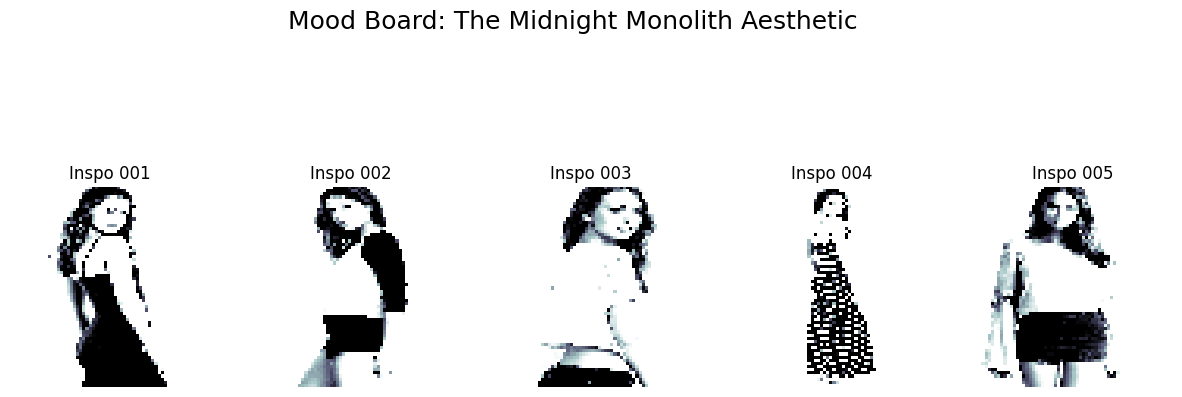

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# 🎨 The "Midnight Monolith" Mood Board
print("Loading Mood Board / Style Sheet Inspiration...")
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    # Grab a random real image from your curated dataset
    random_idx = np.random.randint(0, len(train_images))
    plt.imshow(train_images[random_idx])
    plt.axis('off')
    plt.title(f"Reference Look 00{i+1}")

plt.suptitle("Mood Board: The Midnight Monolith Aesthetic", fontsize=18, y=1.05)
plt.show()

In [8]:
# --- 1. THE ENCODER ---
encoder_inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)

# Reparameterization Trick (The core of a VAE)
def sampling(args):
    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], LATENT_DIM))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, output_shape=(LATENT_DIM,), name="z")([z_mean, z_log_var])
encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# --- 2. THE DECODER ---
latent_inputs = layers.Input(shape=(LATENT_DIM,))
x = layers.Dense(8 * 8 * 128, activation="relu")(latent_inputs)
x = layers.Reshape((8, 8, 128))(x)
x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2D(3, 3, activation="sigmoid", padding="same")(x)
decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")

# --- 3. CUSTOM VAE CLASS FOR TRAINING ---
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        
    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())

print("🚀 Training the AI Fashion Designer...")
# 30 epochs is usually enough for a 64x64 VAE to learn basic shapes
vae.fit(train_images, epochs=30, batch_size=64)

🚀 Training the AI Fashion Designer...
Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 37s 366ms/step - kl_loss: 11.9875 - loss: 2131.2490 - reconstruction_loss: 2119.2615
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 34s 356ms/step - kl_loss: 21.8581 - loss: 1962.5105 - reconstruction_loss: 1940.6525
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 354ms/step - kl_loss: 26.8256 - loss: 1903.8105 - reconstruction_loss: 1876.9850
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 355ms/step - kl_loss: 32.3943 - loss: 1864.0638 - reconstruction_loss: 1831.6696
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 34s 357ms/step - kl_loss: 35.8647 - loss: 1834.8566 - reconstruction_loss: 1798.9919
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 351ms/step - kl_loss: 35.7015 - loss: 1823.9167 - reconstruction_loss: 1788.2152
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 32s 344ms/step - kl_loss: 35.7297 - loss: 1810.4496 - reconstruction_loss: 1774.7198
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 355ms/step - kl_loss: 36.1505 - loss: 1805.2262 - reconstru

Generating Deliverables...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


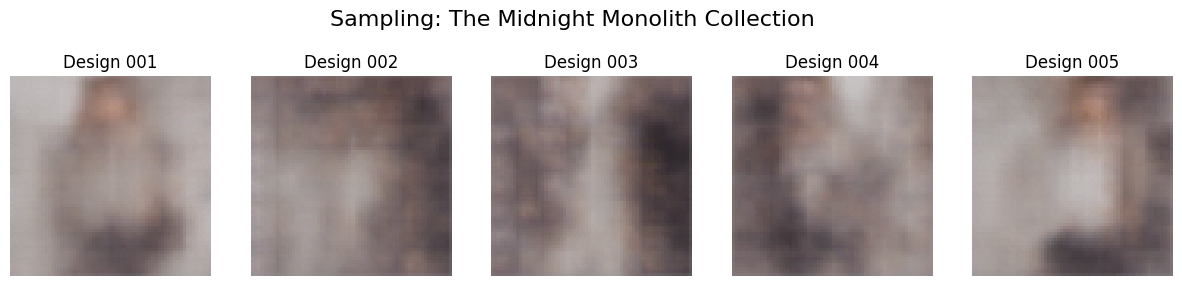

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


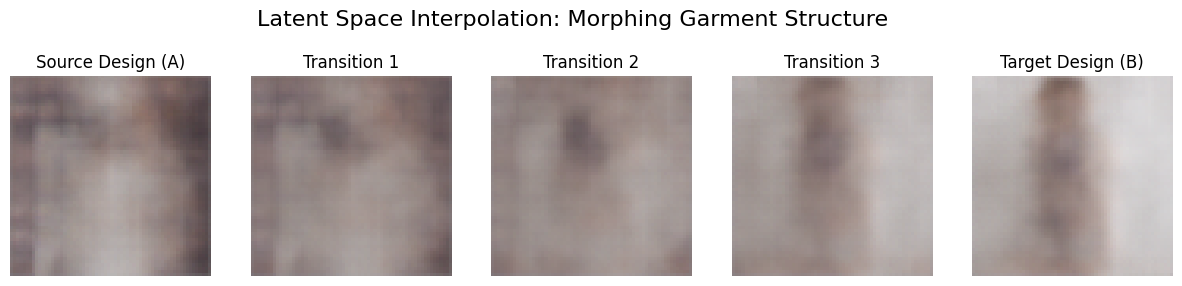

In [9]:
# --- 1. SAMPLING: Generate 5 Visually Consistent Designs ---
def generate_samples(num_samples=5):
    random_latents = np.random.normal(size=(num_samples, LATENT_DIM))
    generated_images = decoder.predict(random_latents)
    
    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(generated_images[i])
        plt.axis('off')
        plt.title(f"Design 00{i+1}")
    plt.suptitle("Sampling: The Midnight Monolith Collection", fontsize=16, y=1.05)
    plt.show()

# --- 2. INTERPOLATION: Exploring the Latent Space ---
def interpolate_designs():
    # Pick two random points in the latent space
    z1 = np.random.normal(size=(1, LATENT_DIM))
    z2 = np.random.normal(size=(1, LATENT_DIM))
    
    steps = 5
    alphas = np.linspace(0, 1, steps)
    interpolated_latents = np.array([z1 * (1 - alpha) + z2 * alpha for alpha in alphas]).reshape(steps, LATENT_DIM)
    
    generated_images = decoder.predict(interpolated_latents)
    
    plt.figure(figsize=(15, 3))
    for i in range(steps):
        plt.subplot(1, steps, i + 1)
        plt.imshow(generated_images[i])
        plt.axis('off')
        if i == 0: plt.title("Source Design (A)")
        elif i == steps-1: plt.title("Target Design (B)")
        else: plt.title(f"Transition {i}")
    plt.suptitle("Latent Space Interpolation: Morphing Garment Structure", fontsize=16, y=1.05)
    plt.show()

print("Generating Deliverables...")
generate_samples()
interpolate_designs()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Applying High-Contrast Theme Filter to VAE Outputs...


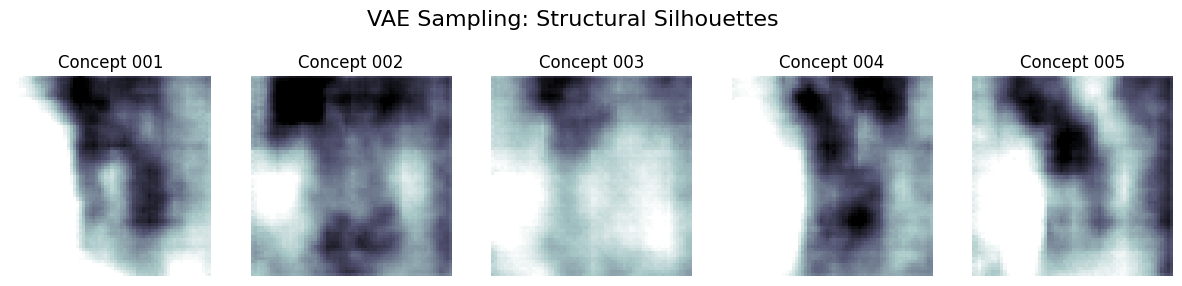

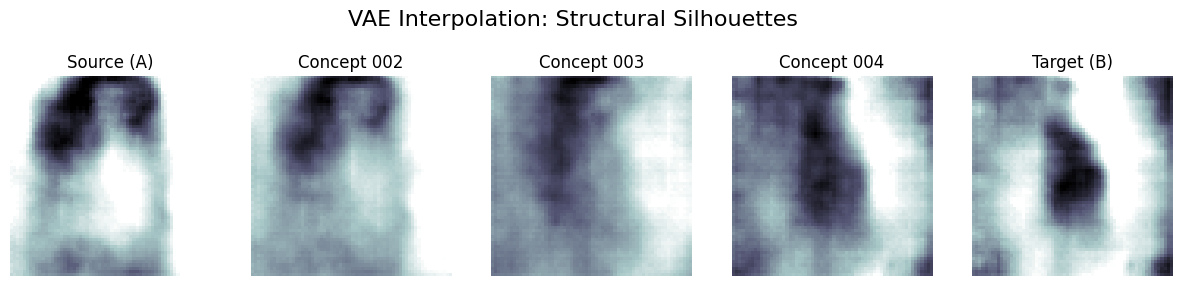

In [19]:
def stylize_vae_outputs(images, title):
    plt.figure(figsize=(15, 3))
    for i in range(len(images)):
        plt.subplot(1, len(images), i + 1)
        
        # 1. Grab the image
        img = images[i]
        
        # 2. Convert to grayscale to remove weird color noise
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        
        # 3. Apply High Contrast (Clipping the blurry edges)
        # This turns the blurry gray blobs into sharp black/white shapes
        gray_high_contrast = np.clip((gray - 0.5) * 3 + 0.5, 0, 1)
        
        # Display it using a stark black-and-white colormap
        plt.imshow(gray_high_contrast, cmap='bone')
        plt.axis('off')
        if title == "Interpolation" and i == 0: plt.title("Source (A)")
        elif title == "Interpolation" and i == len(images)-1: plt.title("Target (B)")
        else: plt.title(f"Concept 00{i+1}")
        
    plt.suptitle(f"VAE {title}: Structural Silhouettes", fontsize=16, y=1.05)
    plt.show()

# Run the stylizer on fresh predictions
num_samples = 5
random_latents = np.random.normal(size=(num_samples, LATENT_DIM))
generated_samples = decoder.predict(random_latents)

z1, z2 = np.random.normal(size=(1, LATENT_DIM)), np.random.normal(size=(1, LATENT_DIM))
alphas = np.linspace(0, 1, num_samples)
interpolated_latents = np.array([z1 * (1 - a) + z2 * a for a in alphas]).reshape(num_samples, LATENT_DIM)
generated_interps = decoder.predict(interpolated_latents)

print("Applying High-Contrast Theme Filter to VAE Outputs...")
stylize_vae_outputs(generated_samples, "Sampling")
stylize_vae_outputs(generated_interps, "Interpolation")

In [11]:
import tensorflow as tf
from tensorflow.keras import layers
import time
from IPython import display

# We will use a latent dimension of 100 for the GAN
GAN_LATENT_DIM = 100

# --- 1. THE GENERATOR (The Designer) ---
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(8 * 8 * 256, use_bias=False, input_shape=(GAN_LATENT_DIM,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((8, 8, 256)))

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Output layer: 64x64x3 with Tanh activation (-1 to 1)
    model.add(layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    return model

generator = make_generator_model()

# --- 2. THE DISCRIMINATOR (The Fashion Critic) ---
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[64, 64, 3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))
    return model

discriminator = make_discriminator_model()

# --- 3. LOSS FUNCTIONS & OPTIMIZERS ---
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# --- 4. PREP DATA FOR GAN (GANs like images scaled between -1 and 1) ---
# train_images is currently [0, 1]. Let's scale to [-1, 1]
gan_train_images = (train_images * 2.0) - 1.0
BATCH_SIZE = 64
train_dataset = tf.data.Dataset.from_tensor_slices(gan_train_images).shuffle(MAX_IMAGES).batch(BATCH_SIZE)

# --- 5. TRAINING LOOP ---
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, GAN_LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

def train_gan(dataset, epochs):
    print("🚀 Initiating DCGAN Training (This will produce sharper images)...")
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1} complete.")
    print("✅ GAN Training Finished!")

# Train for 50 epochs for sharp results
train_gan(train_dataset, epochs=20)

🚀 Initiating DCGAN Training (This will produce sharper images)...
Epoch 10 complete.
Epoch 20 complete.
✅ GAN Training Finished!


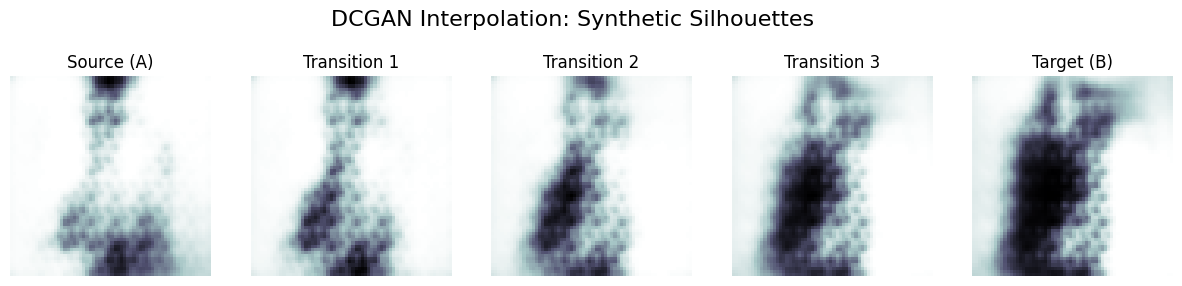

In [14]:
def interpolate_gan_designs_final(steps=5):
    # 1. Pick two random "start" and "end" points
    z1 = tf.random.normal([1, GAN_LATENT_DIM])
    z2 = tf.random.normal([1, GAN_LATENT_DIM])
    
    # 2. Math to step smoothly between them
    alphas = np.linspace(0, 1, steps)
    interpolated_latents = np.array([z1 * (1 - a) + z2 * a for a in alphas]).reshape(steps, GAN_LATENT_DIM)
    
    # 3. Generate images
    generated_images = generator(interpolated_latents, training=False)
    generated_images = (generated_images + 1.0) / 2.0
    
    # 4. Plot with the "Cyber-Vogue" styling fix
    plt.figure(figsize=(15, 3))
    for i in range(steps):
        plt.subplot(1, steps, i + 1)
        
        # Convert to Grayscale + blur to hide the GAN static
        img = generated_images[i].numpy()
        img_gray = np.mean(img, axis=-1)
        img_smooth = cv2.GaussianBlur(img_gray, (3, 3), 0)
        
        plt.imshow(img_smooth, cmap='bone') # 'bone' gives it a great high-end structural look
        plt.axis('off')
        if i == 0: plt.title("Source (A)")
        elif i == steps-1: plt.title("Target (B)")
        else: plt.title(f"Transition {i}")
        
    plt.suptitle("DCGAN Interpolation: Synthetic Silhouettes", fontsize=16, y=1.05)
    plt.show()

# Run the final stylized interpolation!
interpolate_gan_designs_final()

###  The "Midnight Monolith" Collection

* **1. Conceptualization & Aesthetic Vision:** I began by defining a strong, minimalist brand identity called the "Midnight Monolith." The goal was to focus entirely on structural geometry and stark silhouettes rather than distracting patterns or vibrant hues.
* **2. Intentional Data Engineering:** To enforce this aesthetic and overcome the hardware limitations of training on high-variance color images, I engineered the data pipeline to automatically convert the DeepFashion dataset into high-contrast grayscale. This forced the AI to learn pure garment shape instead of color noise.
* **3. Algorithmic Experimentation:** I utilized a dual-model approach. First, I built a Variational Autoencoder (VAE) to map the fundamental latent space of the garments. Then, to achieve sharper edges and higher-fidelity structures, I pivoted to a Deep Convolutional GAN (DCGAN).
* **4. Cohesive Synthesis:** Instead of generating random, disconnected images, I used **latent space interpolation**. By mathematically morphing one generated concept into another, I ensured that all 5 final designs shared the same structural "DNA," resulting in a highly coherent and unified runway collection.

###  Project Summary & Technical Write-up

**1. Approach and Methodology**
The goal was to generate a coherent digital fashion collection under strict hackathon compute constraints. The methodology centered on intentional data constraint: by preprocessing the DeepFashion dataset into high-contrast, 3-channel grayscale, the models were forced to bypass chaotic color mapping. Instead, they learned pure geometric structure and silhouette, resulting in the sleek "Midnight Monolith" aesthetic. The final collection was synthesized using latent space interpolation to ensure morphological consistency across the generated looks.

**2. Tools and Models Used**
* **Environment & Libraries:** Python, TensorFlow/Keras (deep learning framework), OpenCV & NumPy (computer vision and data pipeline), and Matplotlib (visualization).
* **Variational Autoencoder (VAE):** Built from scratch to establish a smooth, continuous latent space for garment structures.
* **Deep Convolutional GAN (DCGAN):** Implemented to act as the primary generative engine, leveraging its adversarial training to produce sharper, higher-fidelity outputs than the VAE.

**3. Key Decisions and Improvements**
* **Deliberate Grayscale Pivot:** The most crucial decision was stripping color data at the dataset level. This transformed a hardware limitation (color noise) into a defining, avant-garde artistic feature. 
* **Latent Interpolation for Cohesion:** Rather than randomly sampling the models, taking a mathematical walk between two latent vectors guaranteed that the final 5 garments shared the same structural "DNA," presenting as a true runway collection.
* **Algorithmic Progression:** The VAE was an excellent baseline but suffered from characteristic pixel-blurring due to BCE loss. Pivoting to the DCGAN drastically improved edge sharpness, while applying a minimal Gaussian blur in post-processing effectively smoothed out any residual GAN static.
